In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pandas as pd
other_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity':[9555,13563,13395,13960,22116,31195,38209,43299,48090,55250,60841,67571,73698,73801,80592,97145,114538,112841,109212,124947,113949,141442,172512,155487,142638,142806,177414,231703],
        'Price':[99.24,124.48,127.39,127.91,223.81,292.54,322.09,432.88,389.23,475.58,574.58,674.35,777.29,975.33,902.64,1089.67,1488.24,1565.78,1623.5,2138.94,1817.87,2133.59,2780.48,3060.53,2756.84,2764.02,3979.99,5246.03]}        
df8=pd.DataFrame(other_fish)

Dataset has 28 records and 3 columns


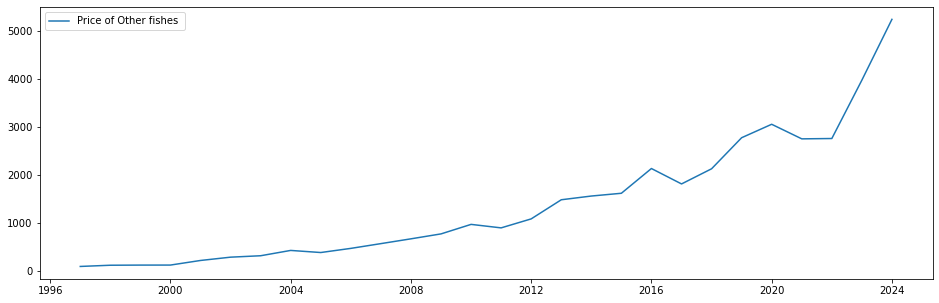

Results of Dickey-Fuller Test:
Test Statistic                  1.103811
p-value                         0.995249
#Lags Used                      9.000000
Number of Observations Used    18.000000
Critical Value (1%)            -3.859073
Critical Value (5%)            -3.042046
Critical Value (10%)           -2.660906
dtype: float64


In [3]:
# Check the dimensionality of the dataset
df8.shape
print("Dataset has {} records and {} columns".format(df8.shape[0], df8.shape[1]))
# Changing the YEAR data type and setting it as index
df8['YEAR'] = pd.Index(sm.tsa.datetools.dates_from_range('1996', '2023'))
df8.index = df8['YEAR']
# Check the data type
del df8['YEAR']
# View the dataset
df8.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df8.index, df8['Price'], label = "Price of Other fishes ")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df8test = adfuller(timeseries, autolag='AIC')
    df8output = pd.Series(df8test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df8test[4].items():
        df8output['Critical Value (%s)'%key] = value
    print (df8output)
# Call the function and run the test

adf_test(df8['Price'])


In [4]:
df8['Price_diff'] =df8['Price'].diff()
df8= df8.dropna()


In [5]:
df8['Price_diff_2'] =df8['Price_diff'].diff()
df8= df8.dropna()


In [6]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df8test = adfuller(df8['Price_diff_2'],autolag='AIC')
df8output=pd.Series(df8test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df8test[4].items():
    df8output['critical value (%s)'%key]= value
print(df8output)

Results of Dickey-fuller test:
Test Statistic :                 -3.686456
p-value :                         0.004308
#lags used :                      6.000000
number of observations used :    19.000000
critical value (1%)              -3.832603
critical value (5%)              -3.031227
critical value (10%)             -2.655520
dtype: float64


In [7]:
df8['Price_diff_3'] =df8['Price_diff_2'].diff()
df8= df8.dropna()

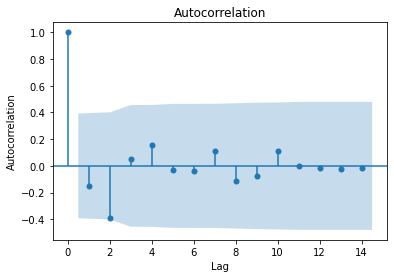

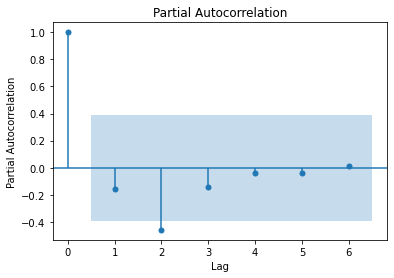

In [9]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df8['Price_diff_2'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=6)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

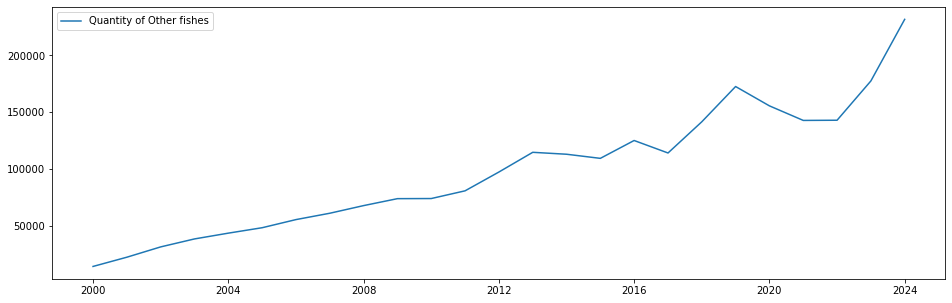

Results of Dickey-fuller test:
Test Statistic :                  2.657643
p-value :                         0.999084
#lags used :                      9.000000
number of observations used :    15.000000
critical value (1%)              -3.964443
critical value (5%)              -3.084908
critical value (10%)             -2.681814
dtype: float64


In [9]:
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df8.index, df8['Quantity'], label = "Quantity of Other fishes")
plt.legend(loc='best')
plt.show()
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df8test = adfuller(df8['Quantity'],autolag='AIC')
df8output=pd.Series(df8test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df8test[4].items():
    df8output['critical value (%s)'%key]= value
print(df8output)

In [11]:
df8['Quantity_diff']=df8['Quantity'].diff()
df8=df8.dropna()


In [12]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df8test = adfuller(df8['Quantity_diff'],autolag='AIC')
df8output=pd.Series(df8test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df8test[4].items():
    df8output['critical value (%s)'%key]= value
print(df8output)

Results of Dickey-fuller test:
Test Statistic :                 -1.061323
p-value :                         0.730247
#lags used :                      9.000000
number of observations used :    14.000000
critical value (1%)              -4.012034
critical value (5%)              -3.104184
critical value (10%)             -2.690987
dtype: float64


In [13]:
df8['Quantity_diff_2']=df8['Quantity_diff'].diff()
df8=df8.dropna()


<ipython-input-13-7c6e1991ffa4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df8['Quantity_diff_2']=df8['Quantity_diff'].diff()


In [14]:
df8['Quantity_diff_3']=df8['Quantity_diff_2'].diff()
df8=df8.dropna()


In [15]:
df8['Quantity_diff_4']=df8['Quantity_diff_3'].diff()
df8=df8.dropna()


In [16]:
df8['Quantity_diff_5']=df8['Quantity_diff_4'].diff()
df8=df8.dropna()


In [17]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df8test = adfuller(df8['Quantity_diff_4'],autolag='AIC')
df8output=pd.Series(df8test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df8test[4].items():
    df8output['critical value (%s)'%key]= value
print(df8output)

Results of Dickey-fuller test:
Test Statistic :                 -4.742933
p-value :                         0.000070
#lags used :                      6.000000
number of observations used :    13.000000
critical value (1%)              -4.068854
critical value (5%)              -3.127149
critical value (10%)             -2.701730
dtype: float64


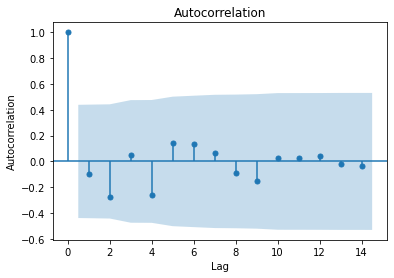

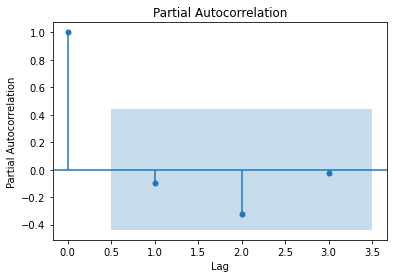

In [20]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df8['Quantity_diff_2'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=3)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

In [18]:
#2 nd objectieve
#Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df8['Quantity'])

# Fit the OLS model
model = sm.OLS(df8['Price'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = -1148.0933081223873 + 0.02620376610018204 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     378.9
Date:                Thu, 10 Aug 2023   Prob (F-statistic):           1.54e-13
Time:                        15:32:19   Log-Likelihood:                -139.95
No. Observations:                  20   AIC:                             283.9
Df Residuals:                      18   BIC:                             285.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

In [19]:
# 3rd obj VAR model
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df8[['Quantity', 'Price']]

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=2) 
print(model)
parameters = results.params
print("Parameter Estimates:")
print(parameters)
print("\n")
# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)

# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)


Parameter Estimates:
                 Quantity       Price
const        52671.876810  659.533569
L1.Quantity      1.207269    0.014506
L1.Price         5.035924    0.910599
L2.Quantity     -1.482391   -0.033986
L2.Price        51.776317    1.093712


Estimated Coefficients:
[[[ 1.20726862e+00  5.03592425e+00]
  [ 1.45063090e-02  9.10598836e-01]]

 [[-1.48239129e+00  5.17763175e+01]
  [-3.39860325e-02  1.09371155e+00]]]
Forecasted Values:
[[ 301890.50320263    7121.08074003]
 [ 381141.63450634    9386.27621787]
 [ 481264.26958306   12263.97186218]
 [ 616433.33498071   16120.84697349]
 [ 799617.19699389   21338.31501371]
 [1046365.44270745   28371.10563658]
 [1378264.57588007   37835.2752395 ]
 [1824971.37275959   50573.81885535]
 [2426432.2740434    67724.72551672]
 [3236288.42197452   90817.79936383]]


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  warnings.warn('No frequency information was'


In [20]:
import pandas as pd
other_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity':[9555,13563,13395,13960,22116,31195,38209,43299,48090,55250,60841,67571,73698,73801,80592,97145,114538,112841,109212,124947,113949,141442,172512,155487,142638,142806,177414,231703],
        'Price':[99.24,124.48,127.39,127.91,223.81,292.54,322.09,432.88,389.23,475.58,574.58,674.35,777.29,975.33,902.64,1089.67,1488.24,1565.78,1623.5,2138.94,1817.87,2133.59,2780.48,3060.53,2756.84,2764.02,3979.99,5246.03]}        
df8=pd.DataFrame(other_fish)

In [21]:
# Assuming you have a DataFrame 'data' containing the price and quantity variables.
# We'll use the ADF test to check for stationarity.
from statsmodels.tsa.stattools import adfuller
data=df8[['Price','Quantity']]
def are_series_stationary(data, threshold=0.05):
    result = adfuller(data)
    p_value = result[1]
    return p_value <= threshold

# Test for stationarity of price and quantity
is_price_stationary = are_series_stationary(df8['Price'])
is_quantity_stationary = are_series_stationary(df8['Quantity'])

# If both series are non-stationary, proceed with cointegration test
if not is_price_stationary and not is_quantity_stationary:
    result = coint_johansen(data, det_order=0, k_ar_diff=1)

    # Get the trace statistics and critical values for different significance levels (e.g., 90%, 95%, 99%)
    trace_statistic = result.lr1
    trace_critical_values = result.cvt[:, 1]  # Use 1% critical value (you can choose other values as well)

    # Find the number of cointegrated vectors (relationships)
    num_cointegrated_vectors = sum(trace_statistic > trace_critical_values)

    if num_cointegrated_vectors > 0:
        print("The variables price and quantity are cointegrated.")
    else:
        print("The variables price and quantity are not cointegrated.")
else:
    print("Both variables should be non-stationary for cointegration testing.")


NameError: name 'coint_johansen' is not defined

In [22]:
 num_cointegrated_vectors

NameError: name 'num_cointegrated_vectors' is not defined

In [23]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# Extract the variables
variables = df8[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit()
print(model)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)
model_fit.predict(10, 0.05)

Forecasted Values:
[[ 290487.23092135    6957.43082772]
 [ 357628.24015541    8949.83319111]
 [ 447034.88543847   11575.8860078 ]
 [ 567317.66047744   15102.57647164]
 [ 728150.35912276   19819.51041514]
 [ 942995.26642412   26121.14918021]
 [1230040.79388891   34540.48587018]
 [1613572.12054523   45789.79888122]
 [2126020.20277774   60820.35043382]
 [2810716.19133512   80903.08741905]]


(array([[ 290487.23092135,    6957.43082772],
        [ 357628.24015541,    8949.83319111],
        [ 447034.88543847,   11575.8860078 ],
        [ 567317.66047744,   15102.57647164],
        [ 728150.35912276,   19819.51041514],
        [ 942995.26642412,   26121.14918021],
        [1230040.79388891,   34540.48587018],
        [1613572.12054523,   45789.79888122],
        [2126020.20277774,   60820.35043382],
        [2810716.19133512,   80903.08741905]]),
 array([[ 264615.05319287,    6440.72164067],
        [ 310312.07505926,    7970.89764102],
        [ 381645.28568334,   10141.42227821],
        [ 482889.06266993,   13140.22087558],
        [ 620809.15924871,   17188.45845839],
        [ 806479.23189838,   22618.45597069],
        [1055278.16310727,   29887.32991925],
        [1387910.94323971,   39608.11713561],
        [1832191.6200816 ,   52601.20344102],
        [2425426.89834054,   69964.01327785]]),
 array([[ 316359.40864983,    7474.14001477],
        [ 404944.40525156,    

In [24]:
coint_vectors

array([[ 2.98500281e-05, -4.66175714e-05],
       [-2.47617474e-03,  2.40423083e-03]])

In [25]:
vecm_res = model.fit()
vecm_res.gamma.round(4)
vecm_res.summary()
print(model)
vecm_res.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,1.0398,0.367,2.829,0.005,0.320,1.760
L1.Price,-37.7701,18.300,-2.064,0.039,-73.638,-1.903
,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,0.0273,0.007,3.721,0.000,0.013,0.042
L1.Price,-0.8950,0.365,-2.449,0.014,-1.611,-0.179
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.2465,0.077,-3.190,0.001,-0.398,-0.095
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.0067,0.002,-4.338,0.000,-0.010,-0.004
,coef,std err,z,P>|z|,[0.025,0.975]


lower bounds of confidence intervals:
[[264615.053   6440.722]
 [310312.075   7970.898]
 [381645.286  10141.422]
 [482889.063  13140.221]
 [620809.159  17188.458]]

point forecasts:
[[290487.231   6957.431]
 [357628.24    8949.833]
 [447034.885  11575.886]
 [567317.66   15102.576]
 [728150.359  19819.51 ]]

upper bounds of confidence intervals:
[[316359.409   7474.14 ]
 [404944.405   9928.769]
 [512424.485  13010.35 ]
 [651746.258  17064.932]
 [835491.559  22450.562]]


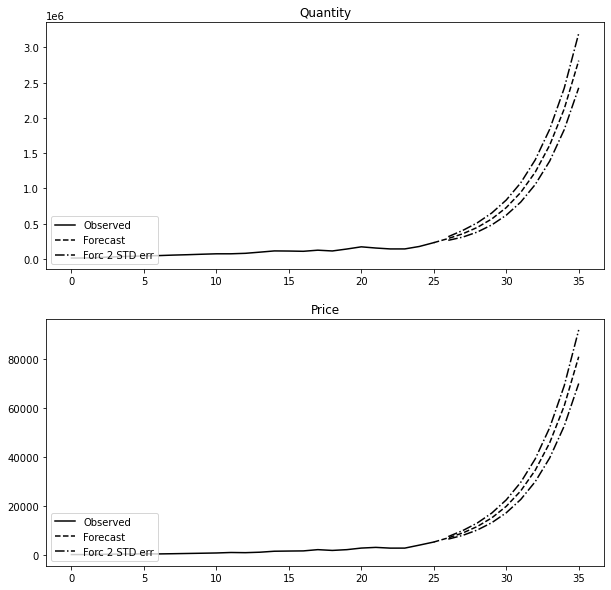

In [6]:
vecm_res.predict(steps=5)
forecast, lower, upper = vecm_res.predict(5, 0.05)
print("lower bounds of confidence intervals:")
print(lower.round(3))
print("\npoint forecasts:")
print(forecast.round(3))
print("\nupper bounds of confidence intervals:")
print(upper.round(3))
vecm_res.plot_forecast(steps=10)
